## 0. Configuration

In [ ]:
from pathlib import Path

# ---- EDIT THIS IF NEEDED ----------------------------------------------------
DATA_PATH = Path("Electricity Consumption 2015-2020.csv")

# -----------------------------------------------------------------------------

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

COUNTRY = "TR"          # dataset is Turkish grid load; change if you swap datasets
RANDOM_STATE = 42

# Backtest protocol
N_SPLITS   = 4          # number of rolling-origin folds
TEST_HOURS = 24 * 90    # 90 days of hourly data per test fold
GAP_HOURS  = 24         # hours skipped between train end and test start

# Set True for a quicker first run (fewer trees). Set False for final numbers.
FAST_MODE = False

print("Data path:", DATA_PATH.resolve())
print("Exists:   ", DATA_PATH.exists())

Data path: C:\Users\ahmed\OneDrive\Desktop\Time series forecasting\Electricity Consumption 2015-2020.csv
Exists:    True


## 1. Imports

In [2]:
import warnings, sys, time
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Optional dependencies -------------------------------------------------------
try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("lightgbm not installed -> falling back to sklearn HistGradientBoostingRegressor.")
    print("   To install:  pip install lightgbm")

try:
    import holidays as holidays_pkg
    HAS_HOLIDAYS = True
except ImportError:
    HAS_HOLIDAYS = False
    print("holidays not installed -> holiday features will be skipped.")
    print("   To install:  pip install holidays")

np.random.seed(RANDOM_STATE)
print("\npandas", pd.__version__, "| numpy", np.__version__, "| python", sys.version.split()[0])


pandas 2.2.2 | numpy 2.2.6 | python 3.11.9


## 2. Load and clean


1. **Dropped rows break lags.** v1 deleted the two zero-consumption rows. In a time series a deleted
   row does not create a hole — it *shifts everything after it*, so `Usage_t-1` for the next row
   actually points two hours back. We reindex onto a complete hourly grid instead.
2. **Those zeros are not bad data.** 2016-03-27 02:00/03:00 is the daylight-saving spring-forward
   gap (Turkey dropped DST later in 2016). Treated as missing and interpolated, not deleted.
3. **`resample('h').ffill()`** count and report every imputed hour so the
   number can go in the README instead of being invisible.

In [3]:
def load_and_clean(path: Path):
    """Return (series, audit_dict) on a complete, gap-free hourly index."""
    raw = pd.read_csv(path)
    audit = {"raw_rows": len(raw)}

    raw["Date"] = pd.to_datetime(raw["Date"], format="%d.%m.%Y")

    # European number format: '.' thousands separator, ',' decimal separator
    col = "Consumption Amount (MWh)"
    if not pd.api.types.is_numeric_dtype(raw[col]):
        raw[col] = (raw[col].astype(str)
                            .str.replace(".", "", regex=False)
                            .str.replace(",", ".", regex=False)
                            .astype(float))

    raw["DateTime"] = pd.to_datetime(raw["Date"].astype(str) + " " + raw["Time"])
    raw = raw[["DateTime", col]].rename(columns={col: "usage"})

    audit["duplicate_timestamps"] = int(raw["DateTime"].duplicated().sum())
    raw = raw.drop_duplicates(subset="DateTime", keep="first").set_index("DateTime").sort_index()

    # Zeros are physically impossible for national grid load -> mark as missing
    audit["zero_values"] = int((raw["usage"] == 0).sum())
    audit["zero_timestamps"] = [str(t) for t in raw.index[raw["usage"] == 0]]
    raw.loc[raw["usage"] == 0, "usage"] = np.nan

    # Reindex onto a COMPLETE hourly grid so lags stay aligned
    full_index = pd.date_range(raw.index.min(), raw.index.max(), freq="h")
    audit["missing_hours_in_file"] = int(len(full_index) - len(raw))
    s = raw["usage"].reindex(full_index)

    audit["nan_before_fill"] = int(s.isna().sum())
    s = s.interpolate(method="time", limit_direction="both")
    audit["nan_after_fill"] = int(s.isna().sum())

    audit["final_rows"] = len(s)
    audit["imputed_pct"] = round(100 * audit["nan_before_fill"] / len(s), 4)
    audit["date_range"] = f"{s.index.min()} -> {s.index.max()}"
    audit["years_covered"] = round((s.index.max() - s.index.min()).days / 365.25, 2)

    s.name = "usage"
    s.index.name = "datetime"
    return s, audit


series, audit = load_and_clean(DATA_PATH)

print("DATA QUALITY AUDIT")
print("-" * 55)
for k, v in audit.items():
    print(f"{k:28s}: {v}")

DATA QUALITY AUDIT
-------------------------------------------------------
raw_rows                    : 39456
duplicate_timestamps        : 1
zero_values                 : 1
zero_timestamps             : ['2016-03-27 02:00:00']
missing_hours_in_file       : 1
nan_before_fill             : 2
nan_after_fill              : 0
final_rows                  : 39456
imputed_pct                 : 0.0051
date_range                  : 2015-12-31 00:00:00 -> 2020-06-30 23:00:00
years_covered               : 4.5


## 3. Feature engineering


- **Lags** — `t-24 ... t-48`, `t-72`, `t-168`, `t-336` (day and week seasonality)
- **Rolling statistics** — mean/std/min/max over 24h, 168h and 720h windows
- **Cyclical encodings** — sin/cos of hour, day-of-week, month, so that hour 23 sits next to hour 0
- **Calendar** — weekend flag, national holidays, hours-since-start trend

**The leakage rule.** Every feature is shifted by `min_lag` before use. For the day-ahead model
`min_lag = 24`, so no feature uses information newer than 24 hours before the target timestamp.
That is exactly the information a grid operator has when producing a day-ahead forecast.

In [4]:
def make_features(s: pd.Series, min_lag: int, country: str = COUNTRY) -> pd.DataFrame:
    """Build a supervised frame. All features are >= min_lag hours older than the target."""
    df = pd.DataFrame({"y": s})
    idx = df.index

    # ---- lag features --------------------------------------------------------
    seasonal = [24, 25, 48, 72, 168, 169, 336, 720]      # day / week / month seasonality
    recent   = list(range(min_lag, min_lag + 24))         # the 24 most recent legal hours
    lags = sorted(set(recent + [L for L in seasonal if L >= min_lag]))
    for L in lags:
        df[f"lag_{L}"] = s.shift(L)

    # ---- rolling statistics (shifted first, so no peeking) -------------------
    base = s.shift(min_lag)
    for w in [24, 168, 720]:
        r = base.rolling(w, min_periods=max(2, w // 4))
        df[f"roll_mean_{w}"] = r.mean()
        df[f"roll_std_{w}"]  = r.std()
        df[f"roll_min_{w}"]  = r.min()
        df[f"roll_max_{w}"]  = r.max()

    # differences: how the recent level compares to the longer-run level
    df["diff_24_168"] = df["roll_mean_24"] - df["roll_mean_168"]
    df["diff_lag_roll"] = df[f"lag_{min_lag}"] - df["roll_mean_168"]

    # ---- calendar of the TARGET timestamp (known in advance, no leakage) -----
    df["hour"]  = idx.hour
    df["dow"]   = idx.dayofweek
    df["month"] = idx.month
    df["doy"]   = idx.dayofyear
    df["year"]  = idx.year
    df["is_weekend"] = (idx.dayofweek >= 5).astype(int)

    # ---- cyclical encodings --------------------------------------------------
    for col, period in [("hour", 24), ("dow", 7), ("month", 12), ("doy", 365.25)]:
        df[f"{col}_sin"] = np.sin(2 * np.pi * df[col] / period)
        df[f"{col}_cos"] = np.cos(2 * np.pi * df[col] / period)

    # ---- holidays ------------------------------------------------------------
    if HAS_HOLIDAYS:
        try:
            hol = holidays_pkg.country_holidays(country, years=range(idx.year.min(), idx.year.max() + 1))
            hol_dates = set(hol.keys())
            d = pd.Series(idx.date, index=idx)
            df["is_holiday"] = d.isin(hol_dates).astype(int).values
            nxt = pd.Series(pd.to_datetime(idx.date) + pd.Timedelta(days=1), index=idx).dt.date
            df["is_holiday_eve"] = nxt.isin(hol_dates).astype(int).values
        except Exception as e:
            print("holiday lookup failed:", e)
            df["is_holiday"] = 0
            df["is_holiday_eve"] = 0
    else:
        df["is_holiday"] = 0
        df["is_holiday_eve"] = 0

    # ---- linear trend --------------------------------------------------------
    df["t_index"] = np.arange(len(df))

    return df.dropna()


# Build both framings
frames = {
    "day_ahead (t+24)": make_features(series, min_lag=24),
    "next_hour (t+1)":  make_features(series, min_lag=1),
}

for name, f in frames.items():
    print(f"{name:20s} rows={len(f):,}  features={f.shape[1]-1}")

frames["day_ahead (t+24)"].head()

day_ahead (t+24)     rows=38,736  features=61
next_hour (t+1)      rows=38,736  features=62


,y,lag_24,lag_25,lag_26,lag_27,lag_28,lag_29,lag_30,lag_31,lag_32,...,hour_cos,dow_sin,dow_cos,month_sin,month_cos,doy_sin,doy_cos,is_holiday,is_holiday_eve,t_index
datetime,,,,,,,,,,,,,,,,,,,,,
2016-01-30 00:00:00,30323.74,30705.61,33343.43,34799.91,34747.11,35585.73,36504.46,38081.88,39566.36,39101.10,...,1.000000,-0.974928,-0.222521,0.5,0.866025,0.493468,0.869764,0,0,720
2016-01-30 01:00:00,28528.18,29000.54,30705.61,33343.43,34799.91,34747.11,35585.73,36504.46,38081.88,39566.36,...,0.965926,-0.974928,-0.222521,0.5,0.866025,0.493468,0.869764,0,0,721
2016-01-30 02:00:00,27243.18,27852.55,29000.54,30705.61,33343.43,34799.91,34747.11,35585.73,36504.46,38081.88,...,0.866025,-0.974928,-0.222521,0.5,0.866025,0.493468,0.869764,0,0,722
2016-01-30 03:00:00,26511.13,27163.15,27852.55,29000.54,30705.61,33343.43,34799.91,34747.11,35585.73,36504.46,...,0.707107,-0.974928,-0.222521,0.5,0.866025,0.493468,0.869764,0,0,723
2016-01-30 04:00:00,26199.54,26971.99,27163.15,27852.55,29000.54,30705.61,33343.43,34799.91,34747.11,35585.73,...,0.500000,-0.974928,-0.222521,0.5,0.866025,0.493468,0.869764,0,0,724


### Leakage self-check



In [5]:
def check_no_leakage(s, frame, min_lag, n=500):
    """Verify every lag column really points >= min_lag hours into the past."""
    sample = frame.sample(min(n, len(frame)), random_state=RANDOM_STATE)
    problems = []
    for col in frame.columns:
        if not col.startswith("lag_"):
            continue
        L = int(col.split("_")[1])
        if L < min_lag:
            problems.append(f"{col} is newer than min_lag={min_lag}")
            continue
        expected = s.reindex(sample.index - pd.Timedelta(hours=L))
        if not np.allclose(sample[col].values, expected.values, equal_nan=True, rtol=1e-9):
            problems.append(f"{col} does not match y shifted by {L}h")
    return problems

for label, min_lag in [("day_ahead (t+24)", 24), ("next_hour (t+1)", 1)]:
    issues = check_no_leakage(series, frames[label], min_lag)
    print(f"{label:20s}: {'PASS - no leakage detected' if not issues else issues}")

day_ahead (t+24)    : PASS - no leakage detected
next_hour (t+1)     : PASS - no leakage detected


## 4. Backtesting protocol


Here: **rolling-origin backtest**, 4 expanding folds, 90 days of test data each, with a 24-hour gap
between train and test so no training row sits inside the forecast horizon.

In [6]:
splitter = TimeSeriesSplit(n_splits=N_SPLITS, test_size=TEST_HOURS, gap=GAP_HOURS)

def describe_folds(frame):
    rows = []
    for i, (tr, te) in enumerate(splitter.split(frame), 1):
        rows.append({
            "fold": i,
            "train_hours": len(tr),
            "train_end": frame.index[tr[-1]].date(),
            "test_start": frame.index[te[0]].date(),
            "test_end": frame.index[te[-1]].date(),
            "test_hours": len(te),
        })
    return pd.DataFrame(rows)

print("Backtest folds (day-ahead frame):")
describe_folds(frames["day_ahead (t+24)"])

Backtest folds (day-ahead frame):


,fold,train_hours,train_end,test_start,test_end,test_hours
0,1,30072,2019-07-05,2019-07-07,2019-10-04,2160
1,2,32232,2019-10-03,2019-10-05,2020-01-02,2160
2,3,34392,2020-01-01,2020-01-03,2020-04-01,2160
3,4,36552,2020-03-31,2020-04-02,2020-06-30,2160


In [7]:
def metrics(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true, float), np.asarray(y_pred, float)
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "MAPE_%": float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100),
    }


def backtest_model(frame, model_fn, name, collect_preds=False):
    """Fit model_fn() fresh on each expanding training window; score on the held-out fold."""
    X = frame.drop(columns="y")
    y = frame["y"]
    rows, preds, importances = [], [], []

    for i, (tr, te) in enumerate(splitter.split(frame), 1):
        model = model_fn()
        t0 = time.time()
        model.fit(X.iloc[tr], y.iloc[tr])
        p = model.predict(X.iloc[te])
        m = metrics(y.iloc[te], p)
        m.update({"model": name, "fold": i, "fit_seconds": round(time.time() - t0, 1)})
        rows.append(m)

        if collect_preds:
            preds.append(pd.DataFrame({"datetime": frame.index[te], "y_true": y.iloc[te].values,
                                       "y_pred": p, "model": name, "fold": i}))
        if hasattr(model, "feature_importances_"):
            importances.append(pd.Series(model.feature_importances_, index=X.columns))
        elif hasattr(model, "steps") and hasattr(model.steps[-1][1], "coef_"):
            importances.append(pd.Series(np.abs(model.steps[-1][1].coef_), index=X.columns))

    res = pd.DataFrame(rows)
    imp = pd.concat(importances, axis=1).mean(axis=1).sort_values(ascending=False) if importances else None
    pr = pd.concat(preds, ignore_index=True) if collect_preds else None
    return res, imp, pr


def backtest_baseline(frame, col, name):
    """A naive baseline is just an existing lag column used directly as the prediction."""
    rows = []
    for i, (tr, te) in enumerate(splitter.split(frame), 1):
        m = metrics(frame["y"].iloc[te], frame[col].iloc[te])
        m.update({"model": name, "fold": i, "fit_seconds": 0.0})
        rows.append(m)
    return pd.DataFrame(rows)

## 5. Baselines



- **Seasonal naive** — same hour, yesterday (`t-24`)
- **Weekly naive** — same hour, same weekday, last week (`t-168`)

Weekly naive usually wins on Mondays and holidays; seasonal naive wins the rest of the time.

In [8]:
da = frames["day_ahead (t+24)"]
nh = frames["next_hour (t+1)"]

baseline_results = pd.concat([
    backtest_baseline(da, "lag_24",  "Seasonal naive (t-24)   [day-ahead]"),
    backtest_baseline(da, "lag_168", "Weekly naive (t-168)    [day-ahead]"),
    backtest_baseline(nh, "lag_1",   "Persistence (t-1)       [next-hour]"),
], ignore_index=True)

baseline_results.groupby("model")[["MAE", "RMSE", "MAPE_%"]].mean().round(2)

,MAE,RMSE,MAPE_%
model,,,
Persistence (t-1) [next-hour],999.74,1283.40,3.12
Seasonal naive (t-24) [day-ahead],1872.50,2944.25,5.98
Weekly naive (t-168) [day-ahead],1719.63,2535.71,5.57


## 6. Models

Three models on the day-ahead task:

- **Ridge** — a linear model on the engineered features. Cheap, and it shows how much of the signal
  is linear once you encode the calendar properly. If Ridge gets close to the trees, that is a
  finding, not a failure.
- **Random Forest (tuned)** — `min_samples_leaf=5` 
- **LightGBM** — the default choice for tabular time series.

In [9]:
n_trees = 150 if FAST_MODE else 300

def make_ridge():
    return make_pipeline(StandardScaler(), Ridge(alpha=1.0))

def make_rf():
    return RandomForestRegressor(
        n_estimators=n_trees, max_depth=None, min_samples_leaf=5,
        max_features=0.5, random_state=RANDOM_STATE, n_jobs=-1,
    )

def make_gbm():
    if HAS_LGB:
        return lgb.LGBMRegressor(
            n_estimators=1200, learning_rate=0.05, num_leaves=63,
            min_child_samples=20, subsample=0.8, subsample_freq=1,
            colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
        )
    return HistGradientBoostingRegressor(
        max_iter=1200, learning_rate=0.05, max_leaf_nodes=63,
        min_samples_leaf=20, random_state=RANDOM_STATE,
    )

MODELS = {
    "Ridge (engineered feats)": make_ridge,
    "Random Forest (tuned)":    make_rf,
    "LightGBM" if HAS_LGB else "HistGradientBoosting": make_gbm,
}

model_results, importance_tables, prediction_tables = [], {}, []

for name, fn in MODELS.items():
    print(f"Backtesting {name} ...", end=" ", flush=True)
    res, imp, pr = backtest_model(da, fn, name, collect_preds=True)
    model_results.append(res)
    if imp is not None:
        importance_tables[name] = imp
    prediction_tables.append(pr)
    print(f"done  (mean MAE {res['MAE'].mean():,.1f})")

model_results = pd.concat(model_results, ignore_index=True)
predictions = pd.concat(prediction_tables, ignore_index=True)

Backtesting Ridge (engineered feats) ... done  (mean MAE 1,127.6)
Backtesting Random Forest (tuned) ... done  (mean MAE 833.7)
Backtesting LightGBM ... done  (mean MAE 841.8)


In [10]:

RUN_SIZE_COMPARISON = True

if RUN_SIZE_COMPARISON:
    tr, te = list(splitter.split(da))[-1]
    X, y = da.drop(columns="y"), da["y"]

    def leaf_stats(model):
        leaves = np.concatenate([
            est.tree_.n_node_samples[est.tree_.children_left == -1] for est in model.estimators_
        ])
        return len(leaves), float(leaves.mean())

    print("Fitting v1-style forest (min_samples_leaf=1, max_depth=30) ...")
    v1 = RandomForestRegressor(n_estimators=100, max_depth=30, min_samples_leaf=1,
                               random_state=RANDOM_STATE, n_jobs=-1).fit(X.iloc[tr], y.iloc[tr])
    print("Fitting v2 tuned forest (min_samples_leaf=5) ...")
    v2 = RandomForestRegressor(n_estimators=100, max_depth=None, min_samples_leaf=5,
                               max_features=0.5, random_state=RANDOM_STATE, n_jobs=-1).fit(X.iloc[tr], y.iloc[tr])

    for tag, mdl in [("v1 style", v1), ("v2 tuned", v2)]:
        n_leaves, mean_samples = leaf_stats(mdl)
        mae = mean_absolute_error(y.iloc[te], mdl.predict(X.iloc[te]))
        print(f"{tag:10s} leaves={n_leaves:>10,}  mean samples/leaf={mean_samples:>6.2f}  "
              f"fold MAE={mae:,.1f}")

Fitting v1-style forest (min_samples_leaf=1, max_depth=30) ...
Fitting v2 tuned forest (min_samples_leaf=5) ...
v1 style   leaves= 2,283,257  mean samples/leaf=  1.01  fold MAE=1,379.6
v2 tuned   leaves=   372,036  mean samples/leaf=  6.21  fold MAE=1,349.4


## 7. Results

In [11]:
all_results = pd.concat([baseline_results, model_results], ignore_index=True)

summary = (all_results.groupby("model")
           .agg(MAE_mean=("MAE", "mean"), MAE_std=("MAE", "std"),
                RMSE_mean=("RMSE", "mean"), MAPE_mean=("MAPE_%", "mean"),
                fit_s=("fit_seconds", "mean"))
           .sort_values("MAE_mean").round(2))

# Improvement over the honest day-ahead baseline
sn_label = [m for m in summary.index if "Seasonal naive" in m][0]
sn = summary.loc[sn_label, "MAE_mean"]
summary["vs_seasonal_naive_%"] = ((sn - summary["MAE_mean"]) / sn * 100).round(1)

print(f"Rolling-origin backtest | {N_SPLITS} folds x {TEST_HOURS//24} days | MAE in MWh\n")
summary

Rolling-origin backtest | 4 folds x 90 days | MAE in MWh



,MAE_mean,MAE_std,RMSE_mean,MAPE_mean,fit_s,vs_seasonal_naive_%
model,,,,,,
Random Forest (tuned),833.74,353.12,1245.31,2.81,59.52,55.5
LightGBM,841.79,320.44,1228.97,2.79,8.00,55.0
Persistence (t-1) [next-hour],999.74,93.51,1283.40,3.12,0.00,46.6
Ridge (engineered feats),1127.62,240.70,1483.83,3.67,0.15,39.8
Weekly naive (t-168) [day-ahead],1719.63,626.93,2535.71,5.57,0.00,8.2
Seasonal naive (t-24) [day-ahead],1872.50,62.35,2944.25,5.98,0.00,0.0


In [12]:
# Per-fold stability: a headline number is only trustworthy if it holds across folds.
pivot = all_results.pivot_table(index="model", columns="fold", values="MAE").round(1)
pivot["spread_%"] = ((pivot.max(axis=1) - pivot.min(axis=1)) / pivot.mean(axis=1) * 100).round(1)
pivot.sort_values(1)

fold,1,2,3,4,spread_%
model,,,,,
Random Forest (tuned),760.3,511.8,725.7,1337.1,99.0
LightGBM,819.7,524.3,738.5,1284.6,90.3
Persistence (t-1) [next-hour],1039.5,1030.4,1067.5,861.5,20.6
Ridge (engineered feats),1134.7,858.2,1076.0,1441.5,51.7
Seasonal naive (t-24) [day-ahead],1921.5,1845.3,1926.0,1797.3,6.9
Weekly naive (t-168) [day-ahead],2374.5,1017.0,1386.2,2100.8,78.9


Best model: Random Forest (tuned)


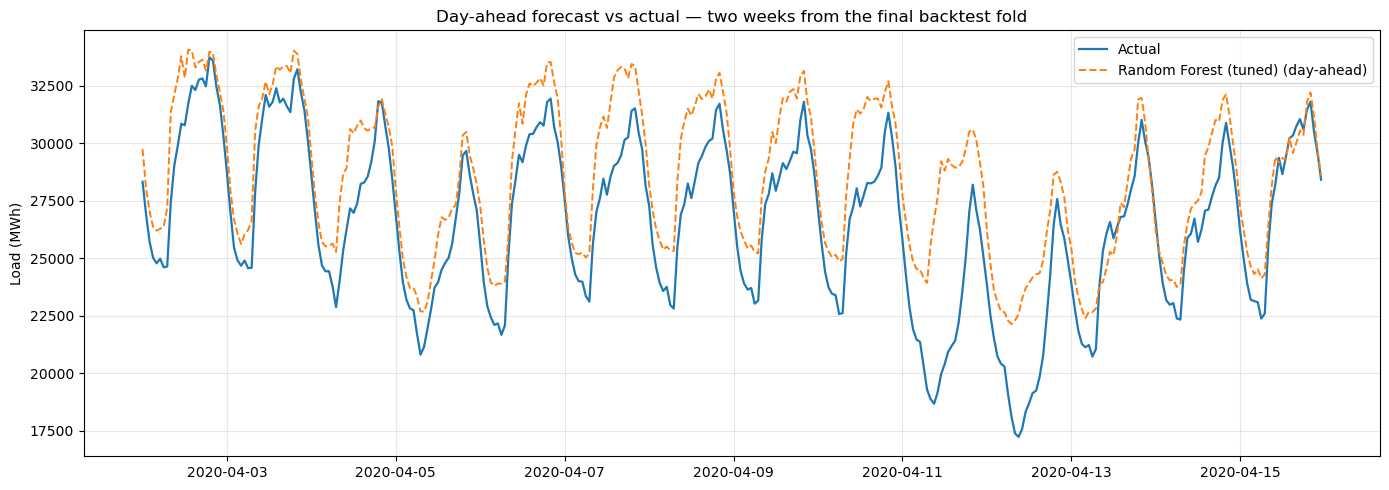

In [13]:
best_model = summary.index[0]
print("Best model:", best_model)

# Two weeks from the final fold — a readable chart, unlike plotting 5,000 hours at once.
final = predictions[(predictions.model == best_model) &
                    (predictions.fold == predictions.fold.max())].set_index("datetime")
window = final.iloc[:24 * 14]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(window.index, window.y_true, label="Actual", lw=1.6)
ax.plot(window.index, window.y_pred, label=f"{best_model} (day-ahead)", lw=1.4, ls="--")
ax.set_title(f"Day-ahead forecast vs actual — two weeks from the final backtest fold")
ax.set_ylabel("Load (MWh)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

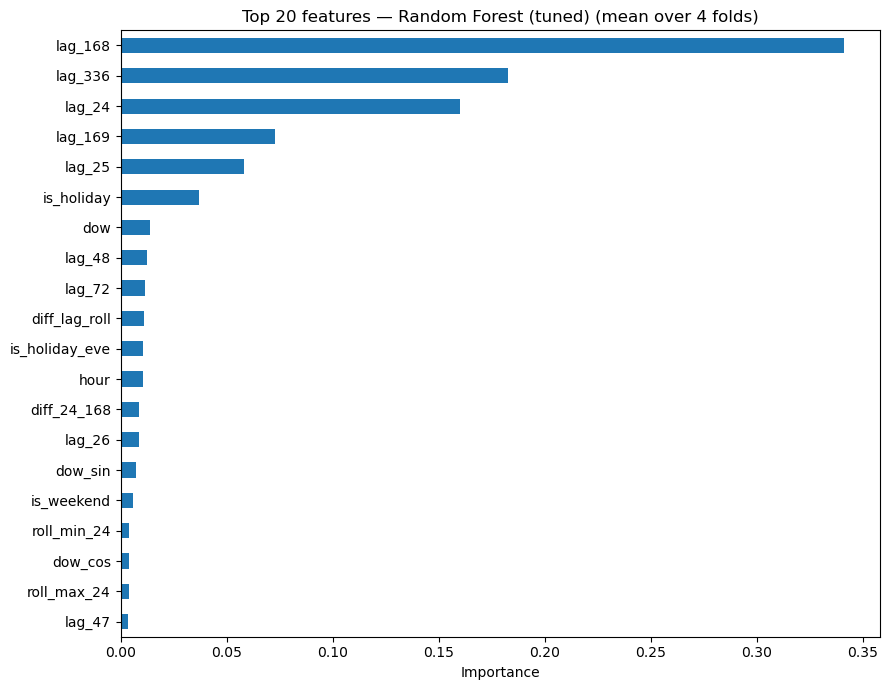

lag_168           0.3411
lag_336           0.1827
lag_24            0.1599
lag_169           0.0728
lag_25            0.0581
is_holiday        0.0368
dow               0.0139
lag_48            0.0122
lag_72            0.0114
diff_lag_roll     0.0108
is_holiday_eve    0.0105
hour              0.0105
diff_24_168       0.0085
lag_26            0.0084
dow_sin           0.0070
is_weekend        0.0058
roll_min_24       0.0040
dow_cos           0.0038
roll_max_24       0.0037
lag_47            0.0035


In [14]:
# Feature importance, averaged across folds
if importance_tables:
    key = best_model if best_model in importance_tables else list(importance_tables)[0]
    top = importance_tables[key].head(20)

    fig, ax = plt.subplots(figsize=(9, 7))
    top.iloc[::-1].plot.barh(ax=ax)
    ax.set_title(f"Top 20 features — {key} (mean over {N_SPLITS} folds)")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()

    print(top.round(4).to_string())

## 8. Save artifacts

In [15]:
all_results.to_csv(OUTPUT_DIR / "backtest_results.csv", index=False)
summary.to_csv(OUTPUT_DIR / "backtest_summary.csv")
predictions.to_csv(OUTPUT_DIR / "predictions.csv", index=False)
pd.Series(audit).to_csv(OUTPUT_DIR / "data_audit.csv")
if importance_tables:
    pd.DataFrame(importance_tables).to_csv(OUTPUT_DIR / "feature_importance.csv")

print("Saved to", OUTPUT_DIR.resolve())
for f in sorted(OUTPUT_DIR.iterdir()):
    print("  -", f.name)

Saved to C:\Users\ahmed\OneDrive\Desktop\Time series forecasting\outputs
  - backtest_results.csv
  - backtest_summary.csv
  - data_audit.csv
  - feature_importance.csv
  - predictions.csv


In [16]:
print("### DATA AUDIT")
for k, v in audit.items():
    print(f"{k}: {v}")

print("\n### BACKTEST SUMMARY")
print(summary.to_string())

print("\n### PER-FOLD MAE")
print(pivot.to_string())

if importance_tables:
    print("\n### TOP 20 FEATURES")
    key = best_model if best_model in importance_tables else list(importance_tables)[0]
    print(f"(model: {key})")
    print(importance_tables[key].head(20).round(4).to_string())

print("\n### ENV")
print(f"lightgbm={HAS_LGB}  holidays={HAS_HOLIDAYS}  fast_mode={FAST_MODE}")
# =============================================================================

### DATA AUDIT
raw_rows: 39456
duplicate_timestamps: 1
zero_values: 1
zero_timestamps: ['2016-03-27 02:00:00']
missing_hours_in_file: 1
nan_before_fill: 2
nan_after_fill: 0
final_rows: 39456
imputed_pct: 0.0051
date_range: 2015-12-31 00:00:00 -> 2020-06-30 23:00:00
years_covered: 4.5

### BACKTEST SUMMARY
                                     MAE_mean  MAE_std  RMSE_mean  MAPE_mean  fit_s  vs_seasonal_naive_%
model                                                                                                   
Random Forest (tuned)                  833.74   353.12    1245.31       2.81  59.52                 55.5
LightGBM                               841.79   320.44    1228.97       2.79   8.00                 55.0
Persistence (t-1)       [next-hour]    999.74    93.51    1283.40       3.12   0.00                 46.6
Ridge (engineered feats)              1127.62   240.70    1483.83       3.67   0.15                 39.8
Weekly naive (t-168)    [day-ahead]   1719.63   626.93    2535.